# PP-Plot

✔ Basic PP-Plot (Normal)

✔ PP-Plot vs Any Custom Distribution

✔ PP-Plot with Confidence Bands

✔ PP-Plot Grid for Multiple Columns

✔ PP-Plot vs Heavy-Tailed Distribution

✔ Beautiful Professional PP-Plot

## Basic PP-Plot (Normal Distribution)

PP-Plot compares cumulative probabilities of sample vs theoretical distribution.

In [ ]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

np.random.seed(42)
data = np.random.normal(loc=0, scale=1, size=300)

# Sorted data
data_sorted = np.sort(data)

# Sample cumulative probabilities
n = len(data)
sample_p = (np.arange(1, n + 1)) / (n + 1)

# Theoretical cumulative probabilities (Normal CDF)
theoretical_p = st.norm.cdf(data_sorted, loc=np.mean(data), scale=np.std(data))

plt.figure(figsize=(6, 6))
plt.plot(theoretical_p, sample_p, "o", alpha=0.6, label="Data")
plt.plot([0, 1], [0, 1], 'r--', lw=2, label="45° Reference Line")

plt.xlabel("Theoretical Probability")
plt.ylabel("Sample Probability")
plt.title("Basic PP-Plot (Normal Distribution)", fontsize=14)
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## PP-Plot vs Any Custom Distribution

Here we compare sample data to a Gamma distribution.

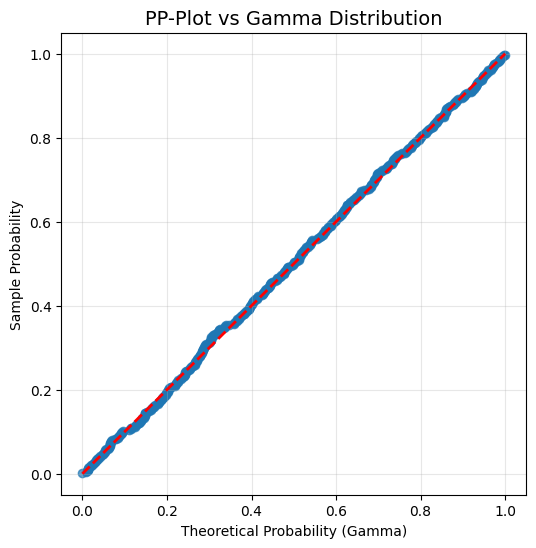

In [1]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

np.random.seed(42)
data = st.gamma(a=4, scale=2).rvs(500)
data_sorted = np.sort(data)
n = len(data_sorted)

# Fit the gamma distribution
params = st.gamma.fit(data_sorted)
gamma_dist = st.gamma(*params)

sample_p = (np.arange(1, n + 1)) / (n + 1)
theoretical_p = gamma_dist.cdf(data_sorted)

plt.figure(figsize=(6, 6))
plt.scatter(theoretical_p, sample_p, alpha=0.7)
plt.plot([0, 1], [0, 1], 'r--', lw=2)

plt.xlabel("Theoretical Probability (Gamma)")
plt.ylabel("Sample Probability")
plt.title("PP-Plot vs Gamma Distribution", fontsize=14)
plt.grid(alpha=0.3)
plt.show()


## Advanced PP-Plot with 95% Confidence Bands

This is similar to QQ bands but on probability scale.

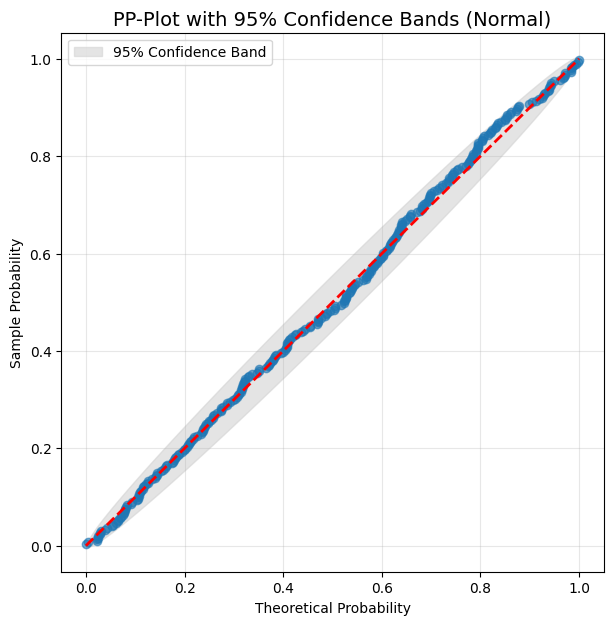

In [2]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

np.random.seed(42)
data = np.random.normal(size=300)
data_sorted = np.sort(data)
n = len(data_sorted)

# Sample & theoretical probabilities
sample_p = (np.arange(1, n + 1)) / (n + 1)
theoretical_p = st.norm.cdf(data_sorted)

# 95% CI for binomial proportions
alpha = 0.05
z = st.norm.ppf(1 - alpha/2)
se = np.sqrt(theoretical_p * (1 - theoretical_p) / n)

lower = theoretical_p - z * se
upper = theoretical_p + z * se

plt.figure(figsize=(7, 7))
plt.plot(theoretical_p, sample_p, "o", alpha=0.6)
plt.plot([0,1],[0,1],"r--", lw=2)

# Confidence band shading
plt.fill_between(theoretical_p, lower, upper, color="lightgray", alpha=0.6,
                 label="95% Confidence Band")

plt.xlabel("Theoretical Probability")
plt.ylabel("Sample Probability")
plt.title("PP-Plot with 95% Confidence Bands (Normal)", fontsize=14)
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## PP-Plots for Multiple Columns (Grid Layout)

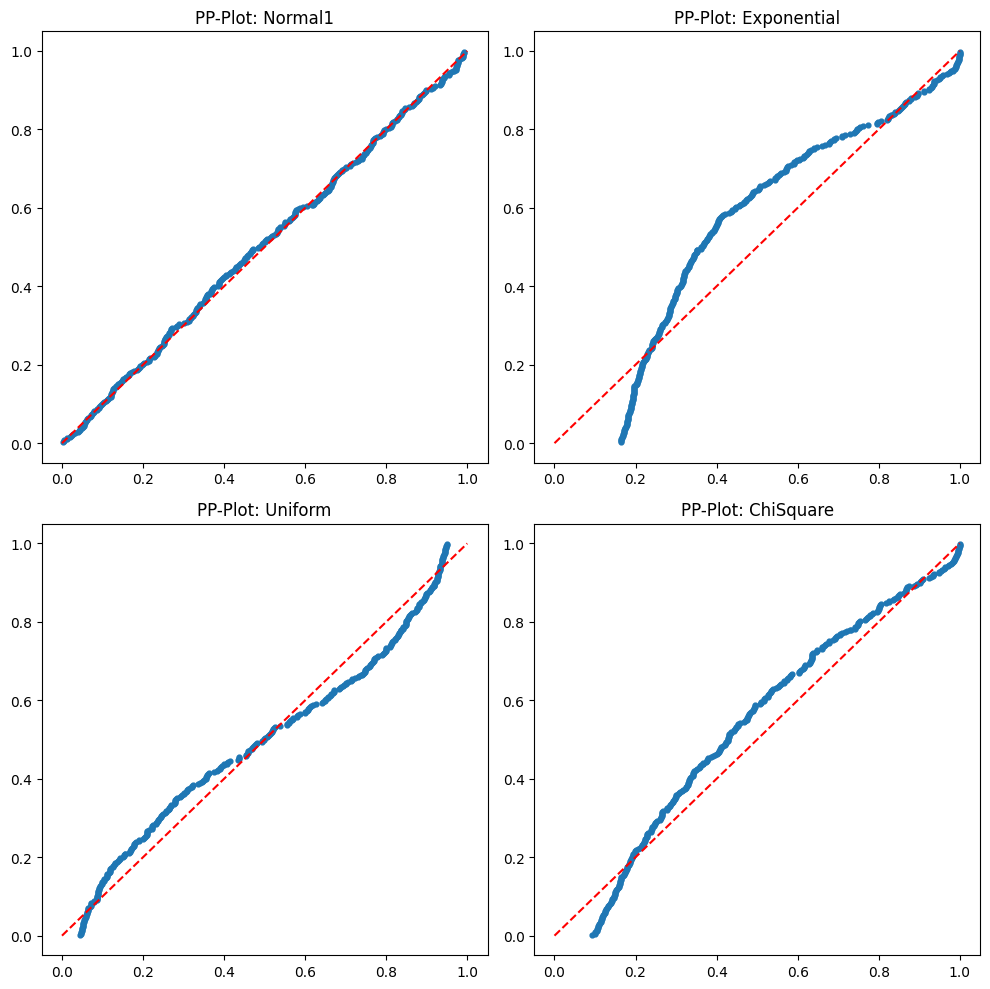

In [3]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt

np.random.seed(0)
df = pd.DataFrame({
    "Normal1": np.random.normal(0, 1, 400),
    "Exponential": np.random.exponential(1, 400),
    "Uniform": np.random.uniform(-2, 2, 400),
    "ChiSquare": np.random.chisquare(3, 400)
})

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for ax, col in zip(axes.flatten(), df.columns):
    data = np.sort(df[col])
    n = len(data)
    
    sample_p = (np.arange(1, n+1)) / (n+1)
    
    # Fit appropriate distribution (example: use normal for all)
    theoretical_p = st.norm.cdf(data, loc=np.mean(data), scale=np.std(data))
    
    ax.scatter(theoretical_p, sample_p, s=12)
    ax.plot([0,1], [0,1], "r--")
    ax.set_title(f"PP-Plot: {col}")

plt.tight_layout()
plt.show()


## PP-Plot vs Heavy-Tailed (Student-t Distribution)

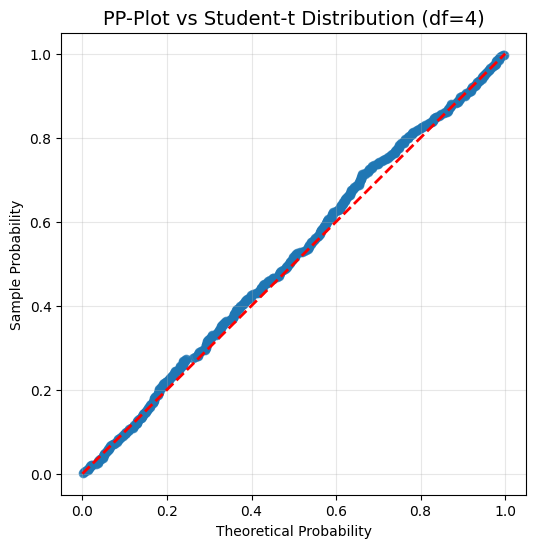

In [4]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

np.random.seed(42)
data = st.t(df=4).rvs(500)
data_sorted = np.sort(data)
n = len(data_sorted)

sample_p = (np.arange(1, n+1)) / (n+1)
theoretical_p = st.t(df=4).cdf(data_sorted)

plt.figure(figsize=(6, 6))
plt.scatter(theoretical_p, sample_p, alpha=0.7)
plt.plot([0,1], [0,1], 'r--', lw=2)

plt.title("PP-Plot vs Student-t Distribution (df=4)", fontsize=14)
plt.xlabel("Theoretical Probability")
plt.ylabel("Sample Probability")
plt.grid(alpha=0.3)
plt.show()


## Professional Publication-Style PP-Plot

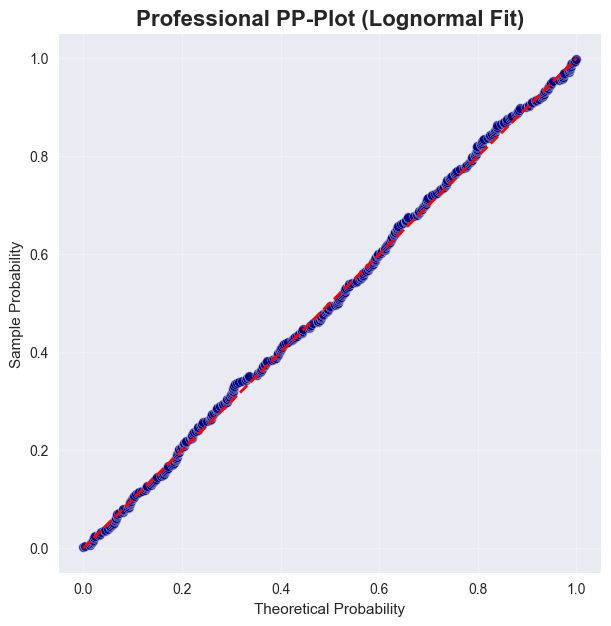

In [6]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

np.random.seed(42)
data = np.random.lognormal(mean=0.5, sigma=0.4, size=400)
data_sorted = np.sort(data)
n = len(data_sorted)

sample_p = (np.arange(1, n+1)) / (n+1)

# Fit lognormal
shape, loc, scale = st.lognorm.fit(data, floc=0)
ln_dist = st.lognorm(shape, loc, scale)

theoretical_p = ln_dist.cdf(data_sorted)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(theoretical_p, sample_p, color="navy", alpha=0.7, edgecolor="white")
ax.plot([0,1], [0,1], "r--", lw=2)

ax.set_title("Professional PP-Plot (Lognormal Fit)", fontsize=16, weight="bold")
ax.set_xlabel("Theoretical Probability")
ax.set_ylabel("Sample Probability")
ax.grid(alpha=0.3)

plt.show()
